# Paper Figures 6–7 — point and mixture GW

Source and target rings are independent samples from radius-4 GMMs; ten points
from a separate ball distribution are added to the target. The 6/7-component
fit and its W2 matrices are shared. Every method is solved exactly once:
Figure 7 displays the raw mixture barycentric maps, and Figure 6 applies nearest
target assignment to those same maps.

The dimensionality claim is limited to the coupling solve (300×310 versus 6×7).
At N=300 the GMM fitting cost means this notebook does not claim end-to-end speedup.


In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

from pgot import set_reproducible

set_reproducible()
OUTPUT_DIR = Path("outputs")
METADATA_DIR = Path("metadata")
OUTPUT_DIR.mkdir(exist_ok=True)
METADATA_DIR.mkdir(exist_ok=True)


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import ot

from pgot import (
    DEFAULT_SEED,
    coupling_marginal_diagnostics,
    fit_figure67_problem,
    generate_figure67_data,
    make_figure6,
    make_figure7,
    solve_figure67,
    write_figure_sidecar,
)

figure67_data = generate_figure67_data(seed=DEFAULT_SEED)
print(
    "source/target radii:",
    np.hypot(*figure67_data["source"][:, :2].T).mean(),
    np.hypot(*figure67_data["target_ring"][:, :2].T).mean(),
)
print("source z standard deviation:", figure67_data["source"][:, 2].std())


source/target radii: 4.005203780929102 4.006823877751217
source z standard deviation: 0.19143823432373971


In [3]:
figure67_problem = fit_figure67_problem(
    figure67_data, random_state=DEFAULT_SEED
)
print(
    "coupling dimensions:",
    (len(figure67_problem["source"]), len(figure67_problem["target"])),
    "->",
    (figure67_problem["source_gmm"].K, figure67_problem["target_gmm"].K),
)


coupling dimensions: (300, 310) -> (6, 7)


In [4]:
figure67_solved = solve_figure67(figure67_problem, paper_lambda=0.01)
print(f"lambda_tilde={figure67_solved['lambda_tilde']:.6f}")
print(
    f"solver lambda: point={figure67_solved['lambda_point']:.6f}, "
    f"component={figure67_solved['lambda_component']:.6f}"
)
for method, key in [
    ("GW2", "coupling_gw"),
    ("PGW2", "coupling_pgw"),
    ("MGW2", "coupling_mgw"),
    ("pMGW2", "coupling_pmgw"),
]:
    print(
        f"{method}: mass={figure67_solved[key].sum():.7f}, "
        f"solve={figure67_solved['solve_ids'][method][:12]}"
    )


lambda_tilde=0.919896
solver lambda: point=0.010000, component=0.013249
GW2: mass=1.0000000, solve=aaf07168ac29
PGW2: mass=0.9677419, solve=7100a94e4f23
MGW2: mass=1.0000000, solve=081db0c37cdb
pMGW2: mass=0.9677419, solve=5a39269c9131


In [5]:
p = ot.unif(len(figure67_problem["source"]))
q = ot.unif(len(figure67_problem["target"]))
source_weights = figure67_problem["source_gmm"].weights
target_weights = figure67_problem["target_gmm"].weights
diagnostics = {
    "GW2": coupling_marginal_diagnostics(
        figure67_solved["coupling_gw"], p, q
    ),
    "PGW2": coupling_marginal_diagnostics(
        figure67_solved["coupling_pgw"], p, q, partial=True
    ),
    "MGW2": coupling_marginal_diagnostics(
        figure67_solved["coupling_mgw"], source_weights, target_weights
    ),
    "pMGW2": coupling_marginal_diagnostics(
        figure67_solved["coupling_pmgw"],
        source_weights,
        target_weights,
        partial=True,
    ),
}

common_inputs = {
    "source_points": figure67_problem["source"],
    "target_ring_points": figure67_problem["target_ring"],
    "target_noise_points": figure67_problem["noise"],
    "source_gmm": {
        "weights": source_weights,
        "means": figure67_problem["source_gmm"].comp_mean,
        "covariances": figure67_problem["source_gmm"].comp_cov,
    },
    "target_gmm": {
        "weights": target_weights,
        "means": figure67_problem["target_gmm"].comp_mean,
        "covariances": figure67_problem["target_gmm"].comp_cov,
    },
    "point_cost_scale": figure67_problem["point_cost_scale"],
    "component_cost_scale": figure67_problem["component_cost_scale"],
    "penalty_conversion": "Lambda = lambda_tilde * balanced mean distortion",
}
method_panels = []
for method, key, solver_lambda in [
    ("GW2", "coupling_gw", None),
    ("PGW2", "coupling_pgw", figure67_solved["lambda_point"]),
    ("MGW2", "coupling_mgw", None),
    ("pMGW2", "coupling_pmgw", figure67_solved["lambda_component"]),
]:
    method_panels.append(
        {
            "method": method,
            "paper_lambda": 0.01 if "P" in method or method.startswith("p") else None,
            "solver_lambda": solver_lambda,
            "lambda_tilde": figure67_solved["lambda_tilde"],
            "solver": (
                "POT gromov_wasserstein"
                if method in {"GW2", "MGW2"}
                else "PGW_Metric partial_gromov_ver1"
            ),
            "solve_id": figure67_solved["solve_ids"][method],
            "coupling": figure67_solved[key],
            "runtime_seconds": figure67_solved["runtime_seconds"].get(
                method, figure67_solved["runtime_seconds"].get(f"{method}_map")
            ),
            **diagnostics[method],
        }
    )


## Figure 6 — barycentric projection followed by nearest-target assignment


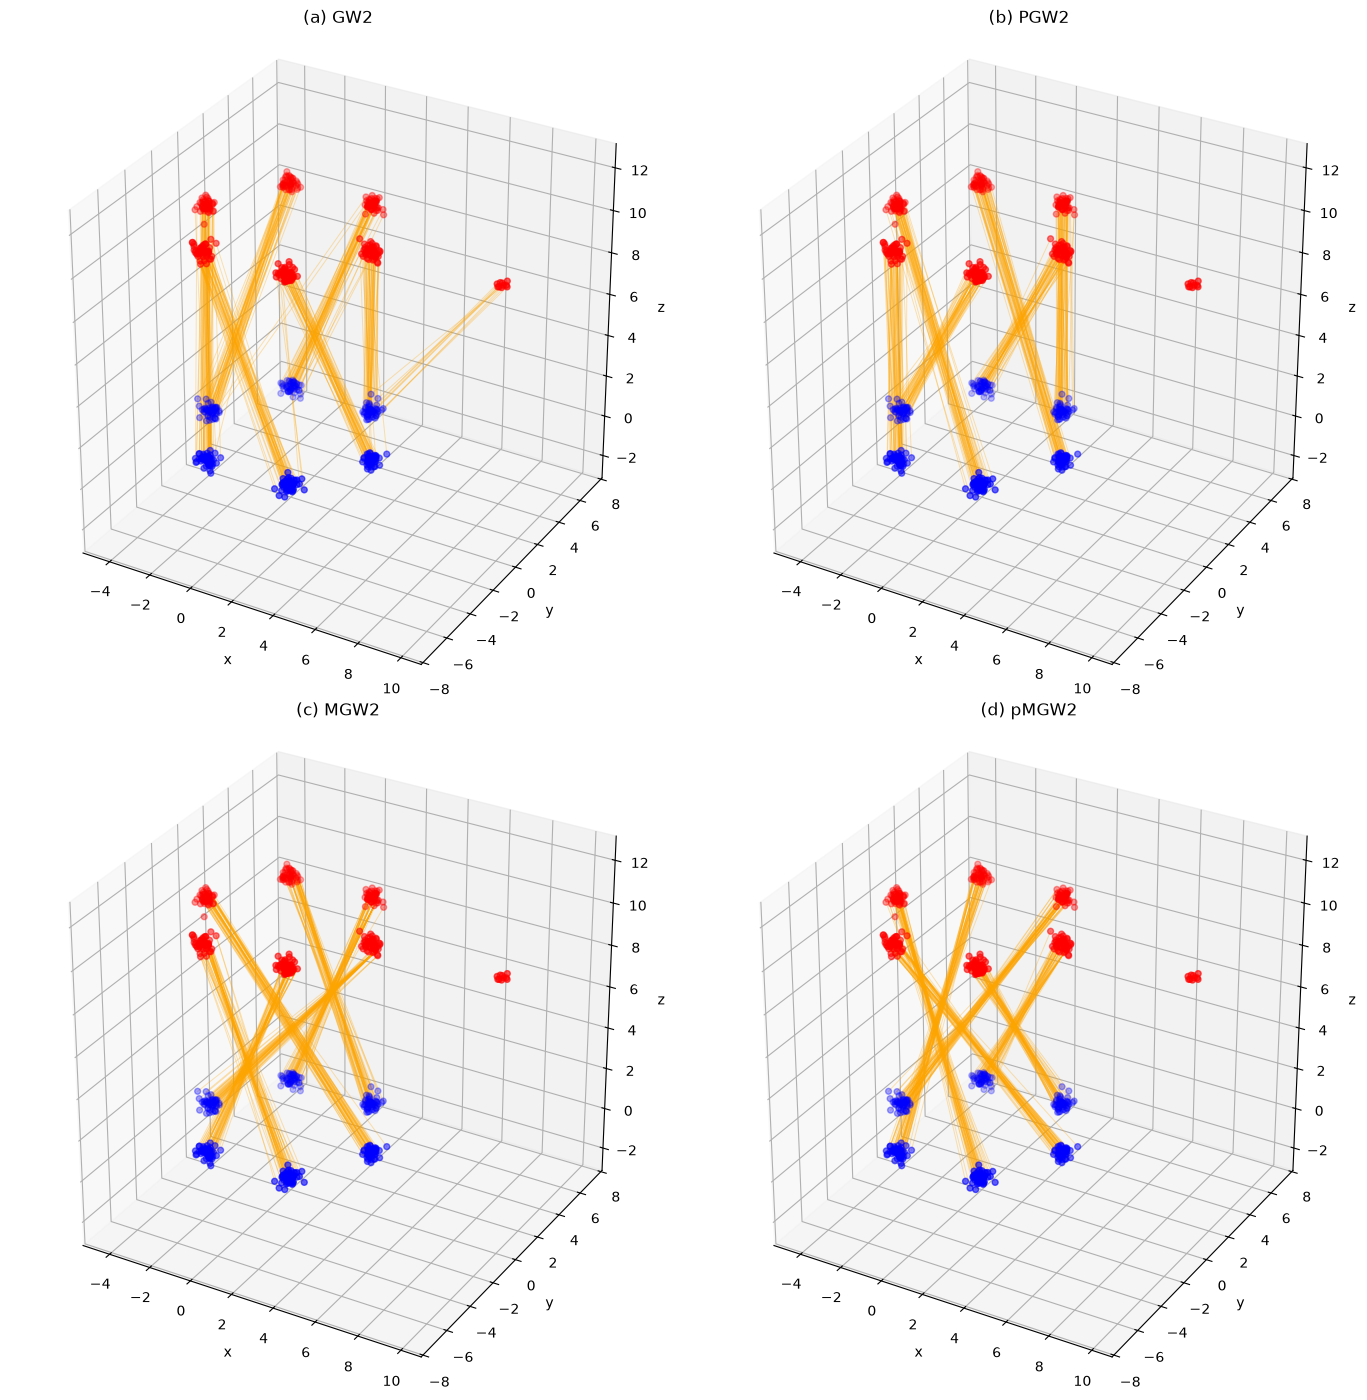

In [6]:
figure6 = make_figure6(figure67_data, figure67_solved)
figure6_path = OUTPUT_DIR / "figure6.pdf"
figure6.savefig(figure6_path, format="pdf", bbox_inches="tight")
write_figure_sidecar(
    METADATA_DIR / "figure6.json",
    figure=6,
    outputs=[figure6_path],
    panels=method_panels,
    inputs=common_inputs,
    seeds={
        "source_sampling": DEFAULT_SEED,
        "target_sampling": DEFAULT_SEED + 1,
        "noise_sampling": DEFAULT_SEED + 2,
        "fit": DEFAULT_SEED,
    },
    notes="All four methods use barycentric projections before nearest assignment.",
)
plt.show()


## Figure 7 — raw maps from the same MGW2 and pMGW2 solves


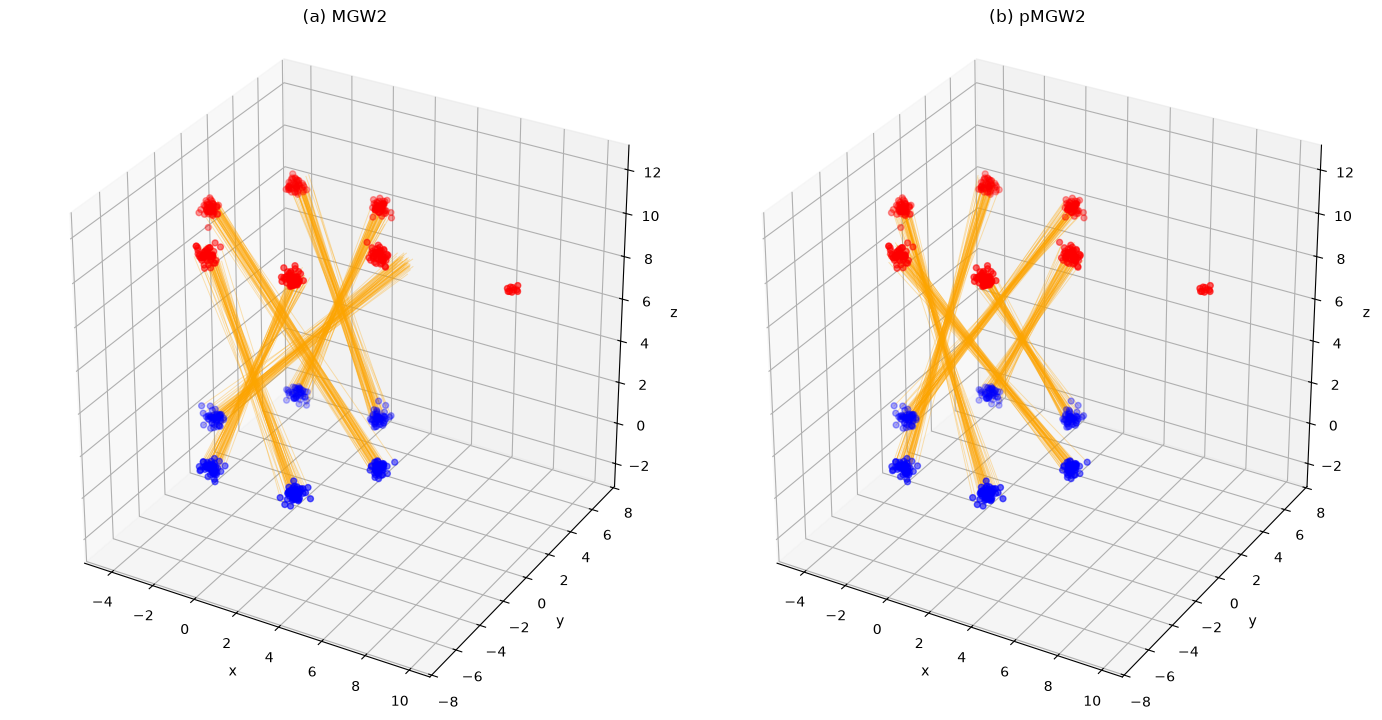

In [7]:
figure7 = make_figure7(figure67_data, figure67_solved)
figure7_path = OUTPUT_DIR / "figure7.pdf"
figure7.savefig(figure7_path, format="pdf", bbox_inches="tight")
mixture_panels = [
    panel for panel in method_panels if panel["method"] in {"MGW2", "pMGW2"}
]
write_figure_sidecar(
    METADATA_DIR / "figure7.json",
    figure=7,
    outputs=[figure7_path],
    panels=mixture_panels,
    inputs=common_inputs,
    seeds={
        "source_sampling": DEFAULT_SEED,
        "target_sampling": DEFAULT_SEED + 1,
        "noise_sampling": DEFAULT_SEED + 2,
        "fit": DEFAULT_SEED,
    },
    notes="solve_id values are identical to the MGW2/pMGW2 panels in Figure 6.",
)
plt.show()
